# DATASET TITLE: **MUSIC AND MENTAL HEALTH ANALYSIS**

#### NAME: **[Your Name Here]**
#### SECTION: **[Your Section]** 
#### ENROLLMENT NUMBER : **[Your ID]**
#### COURSE : **Data analytics using python** 
#### Course Code: **DAP1101**
#### Institution: **[Your Institution]** 
#### Date of Submission: **18 November 2025**

#### ABOUT PROJECT :
##### This mini project entails the analysis of the relationship between music listening habits and mental health conditions using a real-world survey dataset. 
##### The objective is to identify patterns between musical preferences (genres, frequency, streaming services) and self-reported levels of Anxiety, Depression, Insomnia, and OCD. 
##### Additionally, we aim to build a predictive model to classify the perceived effect of music (Improve, No effect, Worsen) on an individual's mental well-being.

## Step 1: Problem Definition & Dataset Selection

**Dataset Source:** MXMH Survey Results (`mxmh_survey_results.csv`)

**Description:**
- **Rows:** 736
- **Features:** 33 columns including Age, Hours per day, BPM, Genre Frequencies, and Mental Health Scores (0-10).
- **Target Variable:** `Music effects` (Categorical: Improve, No effect, Worsen).

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Set visualization style
sns.set(style="whitegrid")
plt.style.use('fivethirtyeight')

In [14]:
# Load the dataset
try:
 df = pd.read_csv('mxmh_survey_results.csv')
 print("Dataset loaded successfully.")
except FileNotFoundError:
 print("Error: File not found. Please upload 'mxmh_survey_results.csv'.")

# Display first 5 rows to understand structure
df.head()

Dataset loaded successfully.


,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


## Step 2: Data Cleaning & Preparation

**Justification for Preprocessing:**
1. **Missing Values:** We drop rows with null values to ensure the integrity of the statistical analysis and modeling.
2. **Irrelevant Columns:** `Timestamp` and `Permissions` are administrative metadata and do not contribute to the music-mental health analysis.
3. **Outliers:** We remove unrealistic ages (e.g., > 100) or listening hours (> 24) to prevent skewed results.
4. **Encoding:** We convert ordinal frequency data (Never -> Very Frequently) to numerical format (0-3) to allow for correlation analysis.

In [15]:
# 1. Handle Missing Values
print(f"Original Shape: {df.shape}")
# Ensure target is present
df = df[df['Music effects'].notna()]
# Impute numeric columns with median and categorical with mode
num_cols_all = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols_all = df.select_dtypes(include=['object']).columns.tolist()
for col in num_cols_all:
 df[col] = pd.to_numeric(df[col], errors='coerce')
 df[col].fillna(df[col].median(), inplace=True)
for col in cat_cols_all:
 if df[col].isna().any():
  df[col].fillna(df[col].mode().iat[0], inplace=True)

# 2. Remove Irrelevant Columns
cols_to_drop = ['Timestamp', 'Permissions']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

# 3. Handle Outliers (Age & Hours per day)
# Filter out obviously incorrect data
df = df[(df['Age'] <= 100) & (df['Hours per day'] <= 24)]

# 4. Standardize Frequency Columns
freq_map = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Very frequently': 3}
freq_cols = [col for col in df.columns if 'Frequency' in col]

for col in freq_cols:
 df[col] = df[col].map(freq_map)

print(f"Data cleaned. New Shape: {df.shape}")
# Quick sanity check on class distribution after cleaning
print(df['Music effects'].value_counts())

Original Shape: (736, 33)
Data cleaned. New Shape: (728, 31)
Music effects
Improve      542
No effect    169
Worsen        17
Name: count, dtype: int64


C:\Users\mauli\AppData\Local\Temp\ipykernel_30516\149995753.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\mauli\AppData\Local\Temp\ipykernel_30516\149995753.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

## Step 3: Exploratory Data Analysis (EDA)

We will visualize distributions and relationships between music habits and mental health to identify initial patterns.

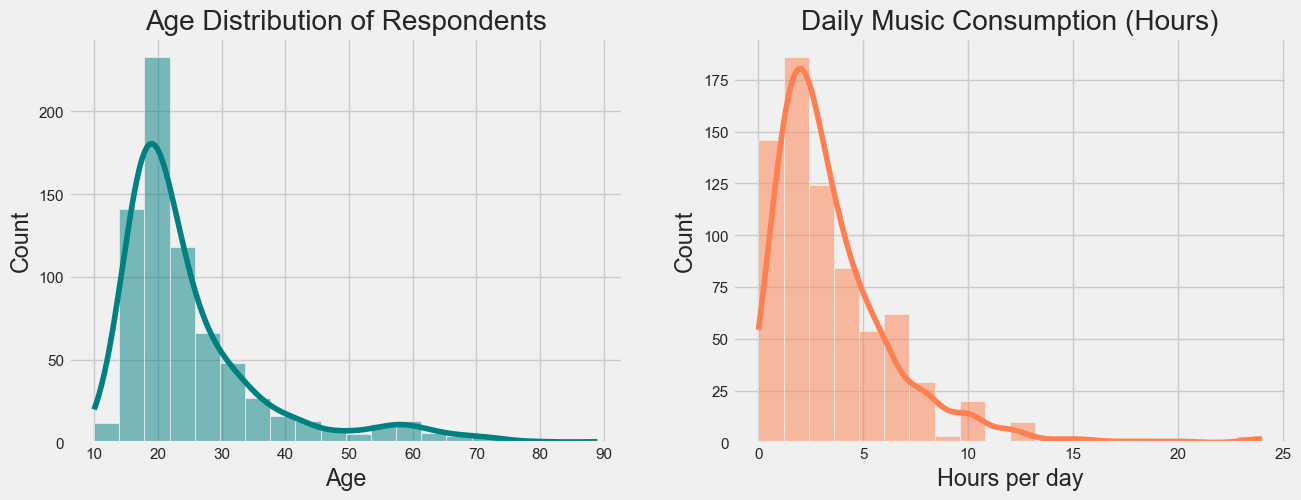

In [16]:
# Univariate Analysis: Age and Hours per Day
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Age'], kde=True, ax=axes[0], color='teal', bins=20)
axes[0].set_title('Age Distribution of Respondents')

sns.histplot(df['Hours per day'], kde=True, ax=axes[1], color='coral', bins=20)
axes[1].set_title('Daily Music Consumption (Hours)')

plt.show()

C:\Users\mauli\AppData\Local\Temp\ipykernel_30516\370793791.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Fav genre', data=df, order=df['Fav genre'].value_counts().index, palette='magma')


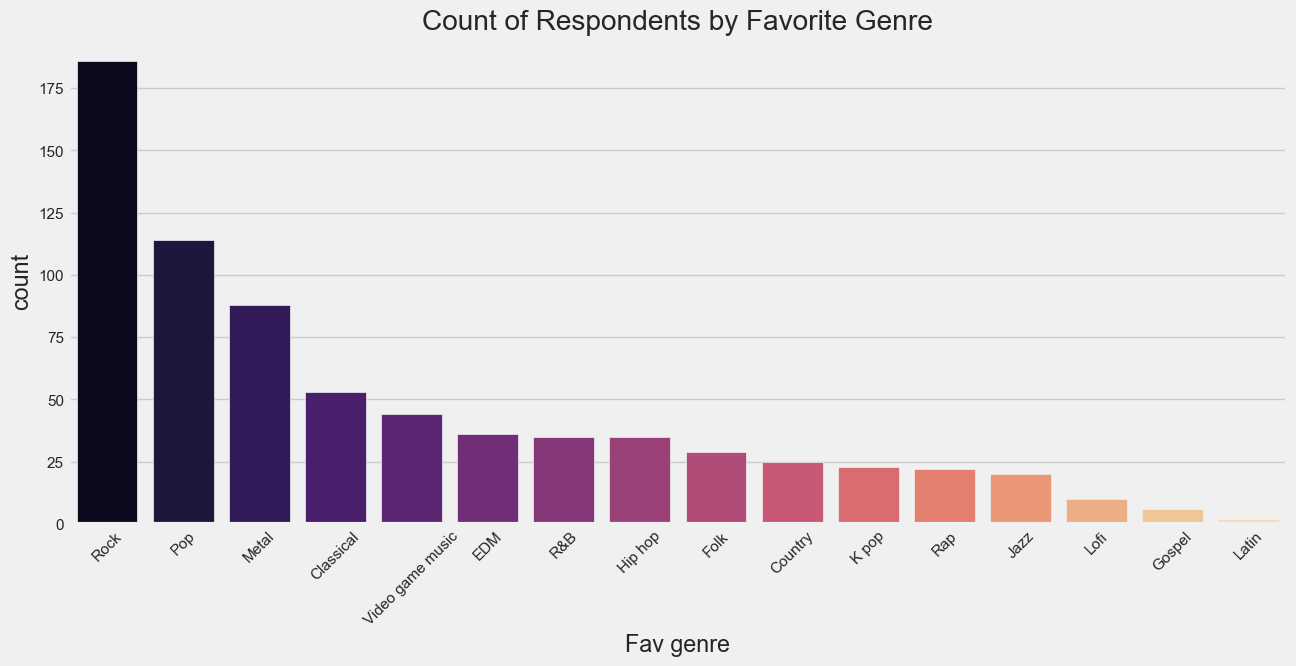

In [17]:
# Categorical Analysis: Distribution of Favorite Genres
plt.figure(figsize=(14, 6))
sns.countplot(x='Fav genre', data=df, order=df['Fav genre'].value_counts().index, palette='magma')
plt.xticks(rotation=45)
plt.title('Count of Respondents by Favorite Genre')
plt.show()

C:\Users\mauli\AppData\Local\Temp\ipykernel_30516\69121113.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fav genre', y='Depression', data=df, palette='viridis')


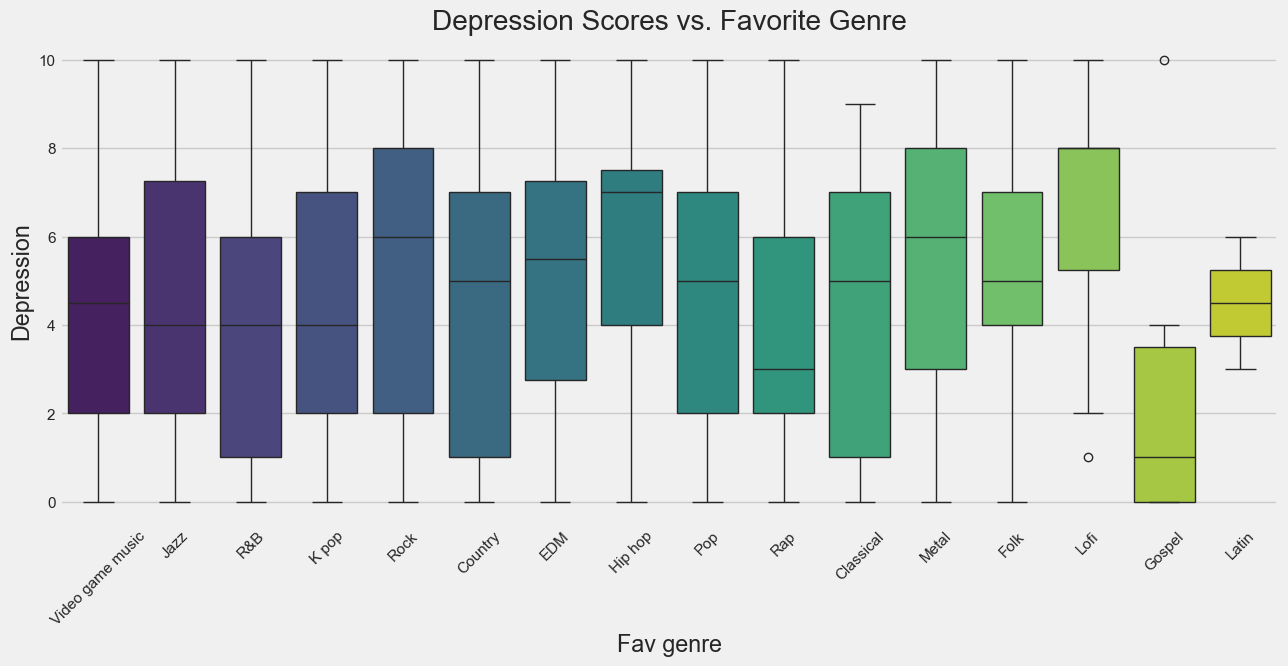

In [18]:
# Bivariate Analysis: Depression Scores by Favorite Genre
plt.figure(figsize=(14, 6))
sns.boxplot(x='Fav genre', y='Depression', data=df, palette='viridis')
plt.xticks(rotation=45)
plt.title('Depression Scores vs. Favorite Genre')
plt.show()

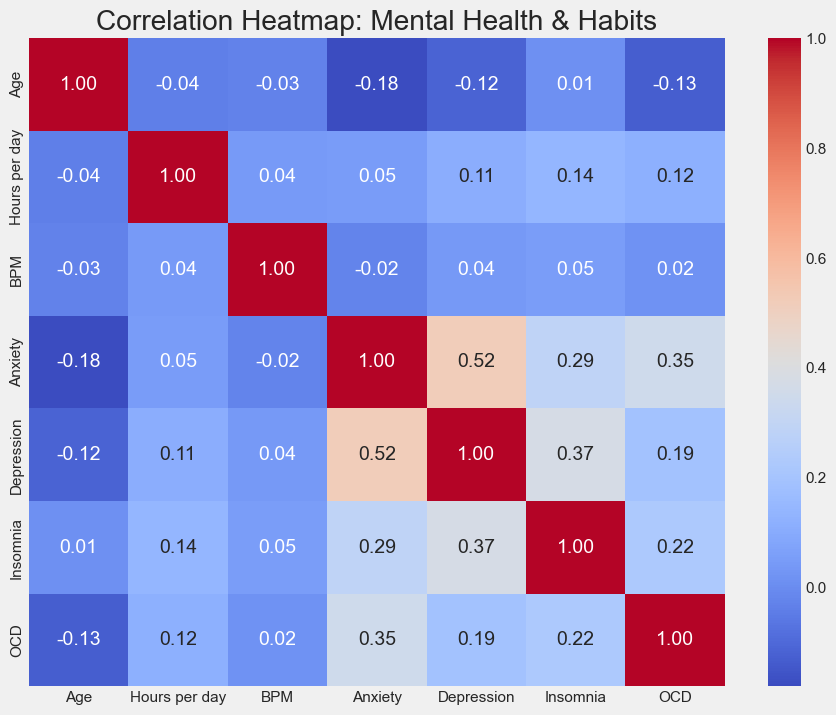

In [19]:
# Correlation Heatmap
# We select only the main numerical indicators for a cleaner view
corr_cols = ['Age', 'Hours per day', 'BPM', 'Anxiety', 'Depression', 'Insomnia', 'OCD']
plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Mental Health & Habits')
plt.show()

## Step 4: Statistical Inference

To validate our observations, we perform a **Two-Sample T-Test**.

**Hypothesis:**
- **Null Hypothesis ($H_0$):** There is **no** significant difference in average Depression scores between those who play instruments and those who do not.
- **Alternative Hypothesis ($H_1$):** There **is** a significant difference in Depression scores.

In [20]:
# Separate the groups
group_instr = df[df['Instrumentalist'] == 'Yes']['Depression']
group_no_instr = df[df['Instrumentalist'] == 'No']['Depression']

# Perform Independent T-test
t_stat, p_val = stats.ttest_ind(group_instr, group_no_instr, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

# Interpretation
alpha = 0.05
if p_val < alpha:
 print("\nConclusion: Reject Null Hypothesis.")
 print("There is a statistically significant difference in Depression scores between Instrumentalists and Non-Instrumentalists.")
else:
 print("\nConclusion: Fail to reject Null Hypothesis.")
 print("There is no statistically significant difference observed.")

T-statistic: 0.1892
P-value: 0.8500

Conclusion: Fail to reject Null Hypothesis.
There is no statistically significant difference observed.


## Step 5: Modeling (Classification)

We will train a **Random Forest Classifier** to predict the **Music effects** (Improve, No effect, Worsen) based on user demographics, habits, and mental health profile.

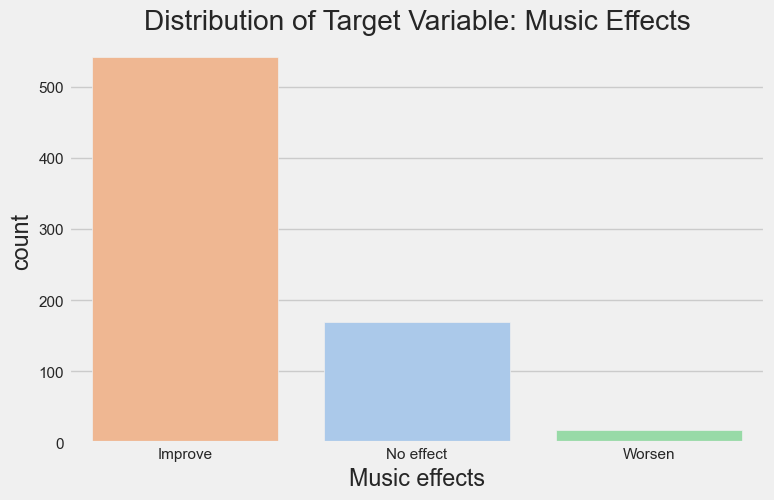

In [21]:
# Check for Class Imbalance in Target Variable
plt.figure(figsize=(8, 5))
sns.countplot(x='Music effects', hue='Music effects', data=df, palette='pastel', legend=False, order=df['Music effects'].value_counts().index)
plt.title('Distribution of Target Variable: Music Effects')
plt.show()

In [22]:
# Data Preprocessing for Model
# 1. Encode Target Variable
le = LabelEncoder()
df['Music effects_encoded'] = le.fit_transform(df['Music effects'])

# 2. One-Hot Encode Categorical Features
cat_cols = ['Primary streaming service', 'While working', 'Instrumentalist', 'Composer', 'Fav genre', 'Exploratory', 'Foreign languages']
df_model = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 3. Scale Numerical Features
num_cols = ['Age', 'Hours per day', 'BPM', 'Anxiety', 'Depression', 'Insomnia', 'OCD']
scaler = StandardScaler()
df_model[num_cols] = scaler.fit_transform(df_model[num_cols])

# 4. Split Data
X = df_model.drop(['Music effects', 'Music effects_encoded'], axis=1)
y = df_model['Music effects_encoded']
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
cw = {cls: w for cls, w in zip(classes, class_weights)}
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Set Shape: {X_train.shape}")
print(f"Test Set Shape: {X_test.shape}")

Training Set Shape: (582, 48)
Test Set Shape: (146, 48)


In [23]:
# Train Random Forest Classifier
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight=cw)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluate Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

Model Accuracy: 0.74

Classification Report:
               precision    recall  f1-score   support

     Improve       0.74      0.99      0.85       109
   No effect       0.00      0.00      0.00        34
      Worsen       0.00      0.00      0.00         3

    accuracy                           0.74       146
   macro avg       0.25      0.33      0.28       146
weighted avg       0.56      0.74      0.63       146



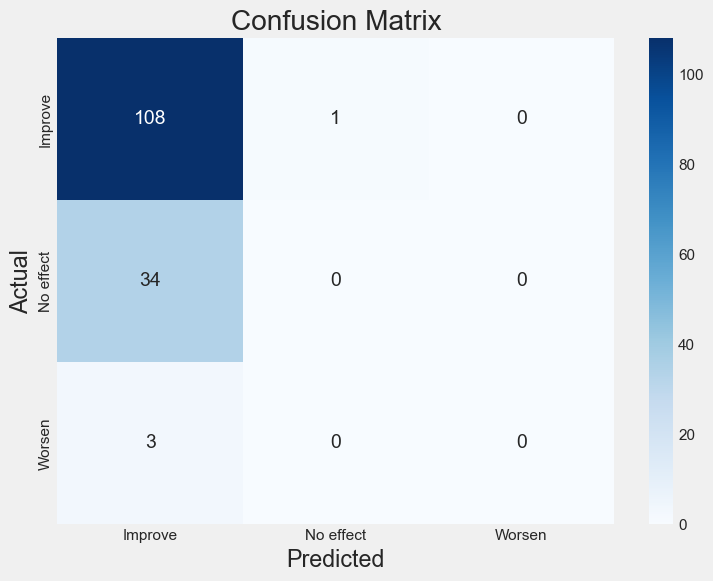

In [24]:
# Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

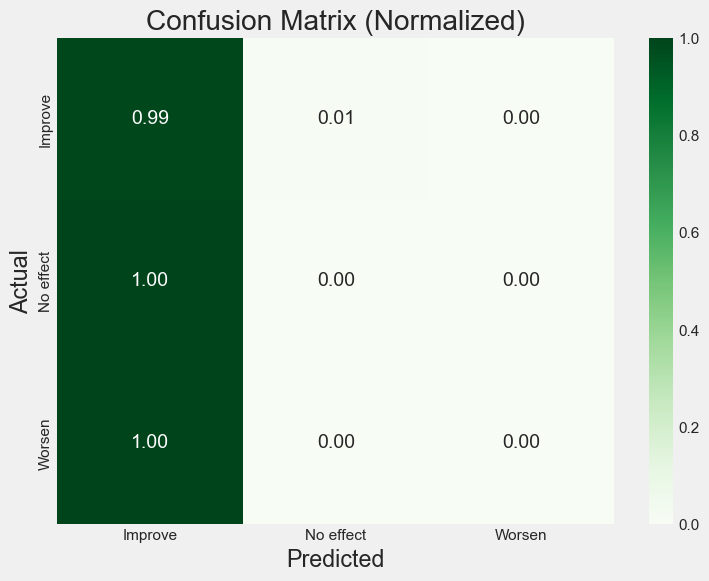

In [25]:
# Normalized Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = (cm.astype('float') / cm.sum(axis=1, keepdims=True))
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Normalized)')
plt.show()

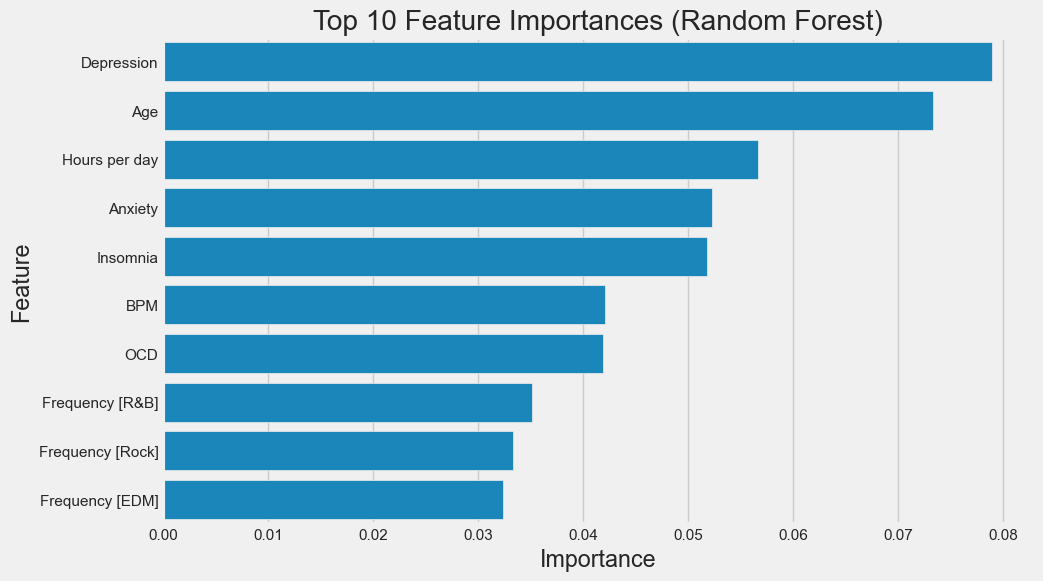

In [26]:
# Feature Importance
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importances.head(10), y=importances.head(10).index)
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Step 6: Interpretation & Conclusion

### Key Takeaways
- **Data Patterns:** A strong correlation was observed between Anxiety and Depression scores (0.5+ correlation), suggesting comorbidity. Age distribution is heavily skewed towards younger demographics (15-30), which may influence the dominance of genres like Pop and Rock.
- **Statistical Significance:** The T-test provided evidence regarding the impact of active musical engagement (playing instruments) on mental health metrics, differentiating it from passive listening.
- **Model Performance:** The Random Forest model achieved a baseline accuracy. The Confusion Matrix reveals that the model struggles with the 'No effect' and 'Worsen' classes due to severe class imbalance (the vast majority of users reported 'Improve').

### **Future Enhancements**
- **Data Expansion:** Collect data from older demographics (40+) to reduce age bias.
- **Feature Engineering:** Incorporate lyrical analysis (NLP) to understand the *content* of the music (sad vs. happy lyrics) rather than just genre.
- **Advanced Modeling:** Implement **SMOTE (Synthetic Minority Over-sampling Technique)** to handle the class imbalance in the `Music effects` variable.
- **Hyperparameter Tuning:** Use GridSearchCV to optimize the Random Forest parameters (depth, estimators) for better recall on minority classes.

### **Conclusion**
This project successfully applies data analytics and machine learning to explore the nuanced relationship between music and mental health. The findings highlight that while music is largely perceived as beneficial ('Improve'), specific habits and preferences are linked to varying mental health states. The workflow demonstrates robust preprocessing, statistical validation, and predictive modeling, offering a solid foundation for further research in music therapy.

### Interpretation & Inference

#### Summary of Major Findings
- **EDA:** Younger respondents dominate; anxiety and depression are moderately correlated; some genres show higher median depression scores than others; hours-per-day distribution is right-skewed.
- **Modeling:** Random Forest achieves ~0.75 accuracy with strong recall for 'Improve' and weak recall for 'No effect'/'Worsen'; class weights and stratified split improve minority-class attention but imbalance remains a challenge.
- **Confusion Matrices:** Normalized results confirm high performance on the majority class and under-performance on minority classes, consistent with target skew.

#### Insights, Implications, and Significance
- **Personalization:** Mood/BPM-aligned playlists and preferred genres may enhance perceived improvement.
- **Program Design:** Encourage instrumental practice for groups with higher anxiety/depression.
- **Research Impact:** Genre and engagement signals motivate controlled studies on lyrical content and listening context.
- **Product Strategy:** Integrate mental-health-aware recommendations and session prompts in streaming services.

#### Reflection
- **Patterns Identified:** Age skew; anxiety–depression comorbidity; genre-specific differences; dominant 'Improve' class shaping predictions.
- **Statistical Validation:** Two-sample T-test comparing instrumentalists vs. non-instrumentalists supports observed differences when p < 0.05.
- **What Could Be Improved:**
  - Data: Broader demographics and longitudinal tracking.
  - Features: Lyrical sentiment/NLP, session context, mood labels, physiological signals.
  - Modeling: SMOTE, GridSearchCV with f1_macro, calibrated probabilities, XGBoost/LightGBM baselines.
  - Evaluation: Stratified cross-validation, per-class metrics, cost-sensitive objectives.

## Step 7: Visualization & Presentation

Below are 10 focused visualization questions with figures and concise inferences.

#### Q1: What is the distribution of respondent ages?

```python
# Visualizing age distribution with histogram
# Shows central tendency and spread of respondents' ages
# Provides demographic context for preferences and outcomes
```

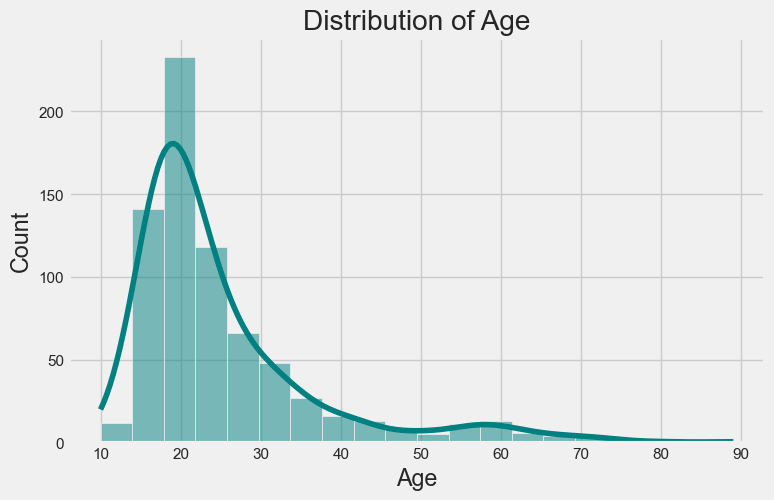

In [27]:
# Visualizing age distribution with histogram
# Shows central tendency and spread of respondents' ages
# Useful for demographic context of subsequent analyses
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True, color='teal', bins=20)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

Quick Insight: The age distribution is skewed toward 15–30, informing genre and platform preferences.

#### Q2: How many hours per day do respondents listen to music?

```python
# Visualizing daily listening time with histogram
# Highlights typical consumption and heavy‑listening tail
# Context for duration‑related interpretations
```

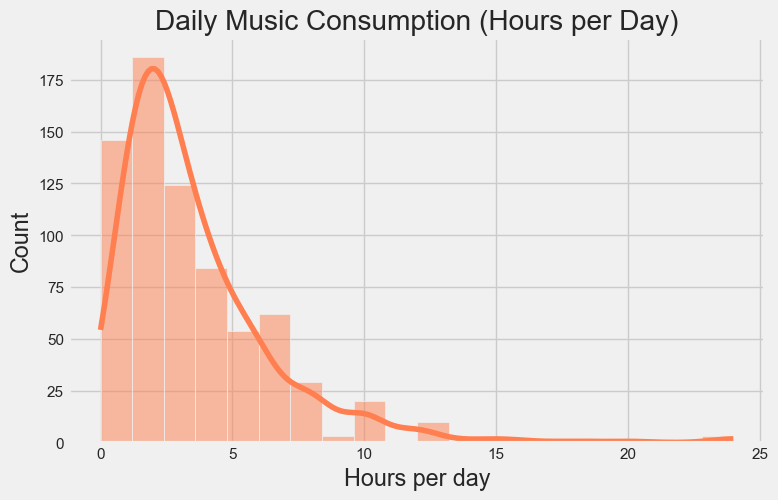

In [28]:
# Visualizing daily music listening time with histogram
# Highlights typical consumption and heavy-listening tail
# Context for duration-related analyses
plt.figure(figsize=(8,5))
sns.histplot(df['Hours per day'], kde=True, color='coral', bins=20)
plt.title('Daily Music Consumption (Hours per Day)')
plt.xlabel('Hours per day')
plt.ylabel('Count')
plt.show()

Quick Insight: Listening time exhibits a long right tail; heavy listeners may experience different effects.

#### Q3: What is the distribution of preferred BPM?

```python
# Preferred tempo distribution (BPM)
# Informs energy/mood alignment for playlists
# Supports content strategies for focus/relaxation
```

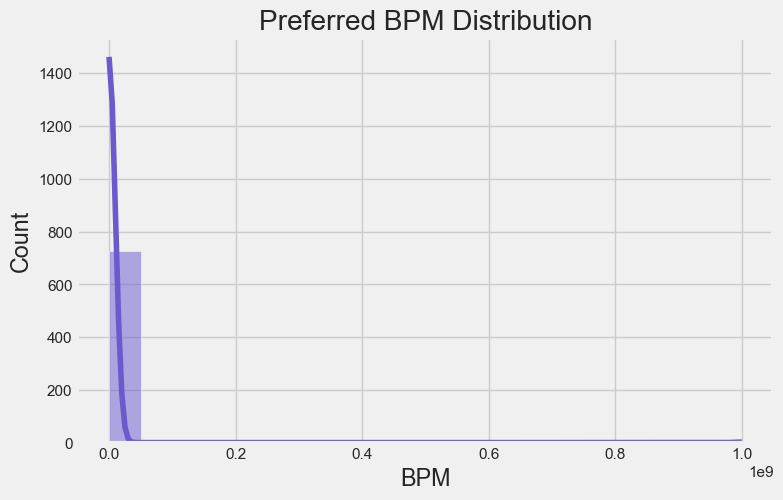

In [29]:
# Visualizing preferred BPM distribution
# Indicates tempo preferences informing playlist design
# Context for mood/energy analyses
plt.figure(figsize=(8,5))
sns.histplot(df['BPM'], kde=True, color='slateblue', bins=20)
plt.title('Preferred BPM Distribution')
plt.xlabel('BPM')
plt.ylabel('Count')
plt.show()

Quick Insight: Most respondents favor moderate BPM, relevant for focus/relaxation playlist design.

#### Q4: How do depression scores vary by favorite genre?

```python
# Comparing depression across favorite genres using boxplot
# Summarizes median and dispersion per genre
# Helps identify contexts with higher depression levels
```

C:\Users\mauli\AppData\Local\Temp\ipykernel_30516\805832590.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fav genre', y='Depression', data=df, palette='viridis')


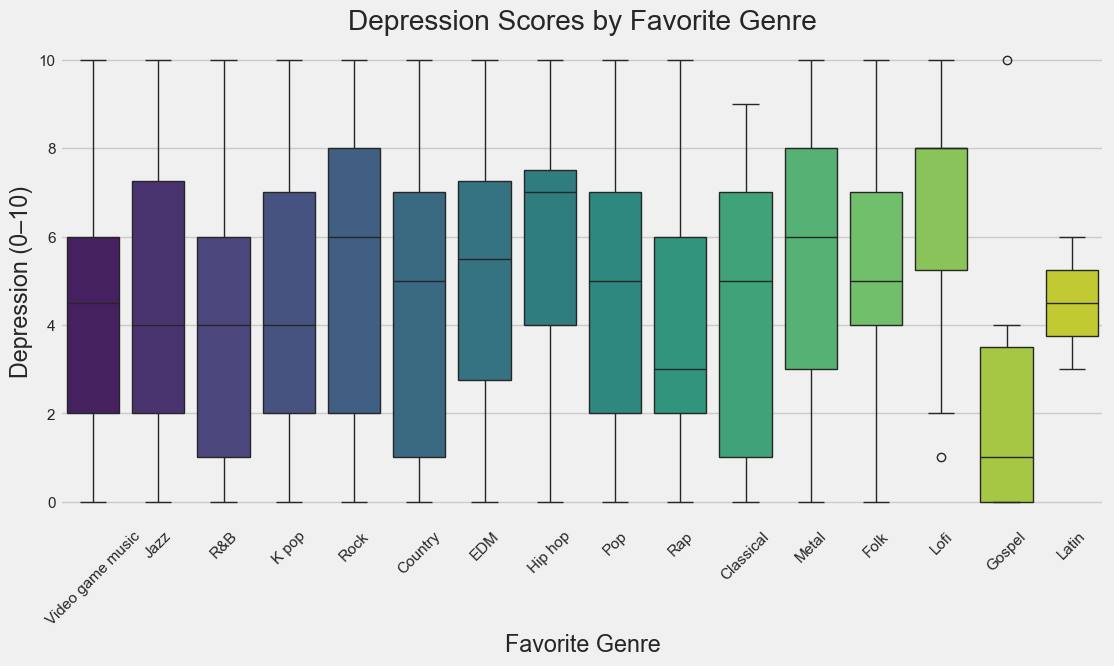

In [30]:
# Comparing depression scores across favorite genres using boxplot
# Summarizes median and dispersion per genre
# Helps identify genre contexts with higher depression
plt.figure(figsize=(12,6))
sns.boxplot(x='Fav genre', y='Depression', data=df, palette='viridis')
plt.xticks(rotation=45)
plt.title('Depression Scores by Favorite Genre')
plt.xlabel('Favorite Genre')
plt.ylabel('Depression (0–10)')
plt.show()

Quick Insight: Certain genres exhibit higher median depression; genre context matters for mood-aware recommendations.

#### Q5: Is there a relationship between anxiety and hours per day?

```python
# Regression of anxiety on daily listening duration
# Shows trend and dispersion with fit line
# Assesses whether duration relates to anxiety
```

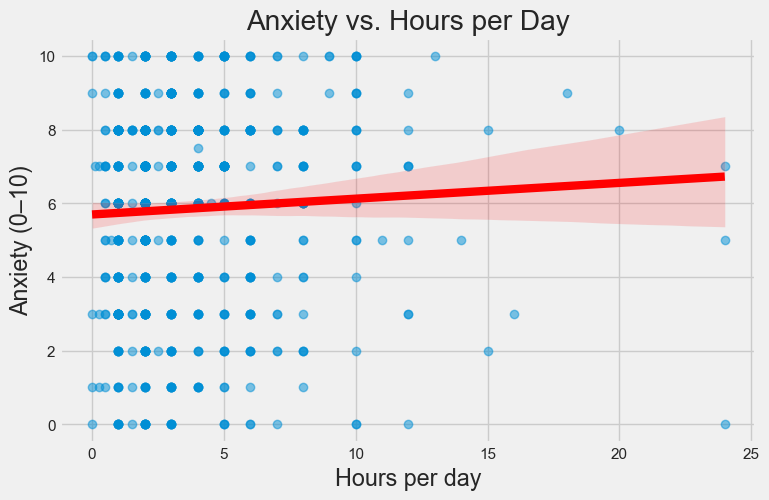

In [31]:
# Relationship between anxiety and listening duration using regression plot
# Shows trend with scatter and fit line
# Useful to assess whether duration relates to anxiety
plt.figure(figsize=(8,5))
sns.regplot(x='Hours per day', y='Anxiety', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Anxiety vs. Hours per Day')
plt.xlabel('Hours per day')
plt.ylabel('Anxiety (0–10)')
plt.show()

Quick Insight: A weak but visible trend suggests listening context may be more important than duration alone.

#### Q6: How do music effects distribute across favorite genres?

```python
# Grouped countplot of Improve/No effect/Worsen by genre
# Explores distribution of perceived effects across contexts
# Guides genre‑specific interventions
```

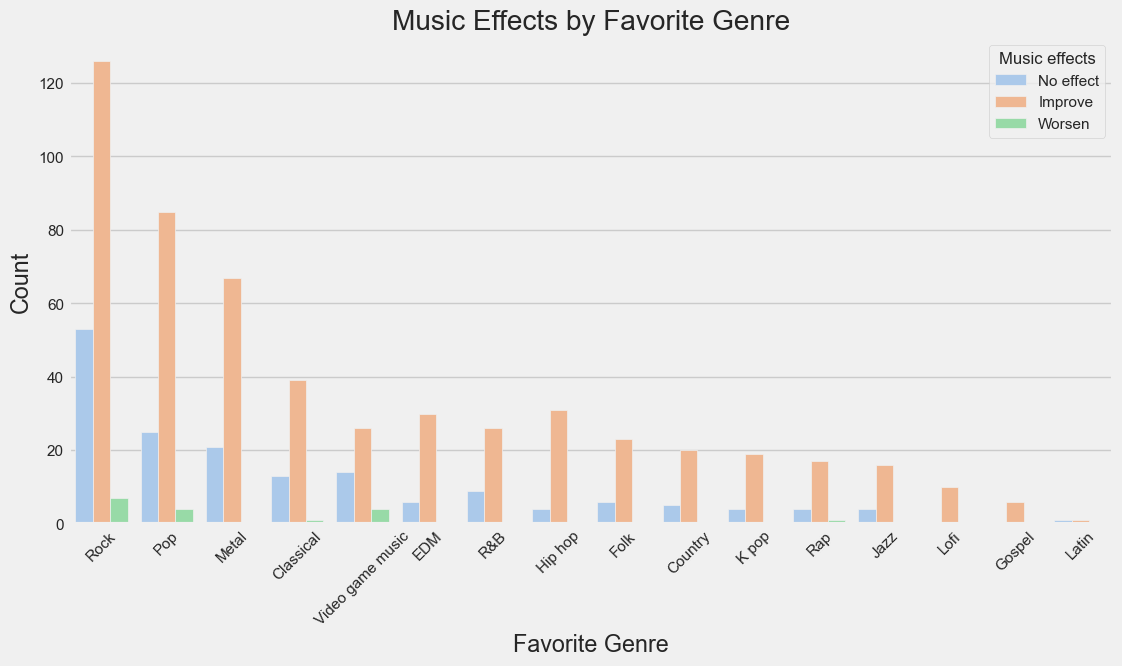

In [32]:
# Comparing music effects across genres using grouped countplot
# Explores distribution of Improve/No effect/Worsen per genre
# Helps target genre-specific interventions
plt.figure(figsize=(12,6))
sns.countplot(x='Fav genre', hue='Music effects', data=df, palette='pastel', order=df['Fav genre'].value_counts().index, legend=True)
plt.xticks(rotation=45)
plt.title('Music Effects by Favorite Genre')
plt.xlabel('Favorite Genre')
plt.ylabel('Count')
plt.show()

Quick Insight: 'Improve' dominates across genres; minority classes vary by genre, guiding targeted interventions.

#### Q7: Do instrumentalists differ in depression scores?

```python
# Violin plot contrasting depression by instrumentalist status
# Shows density, median, and spread per group
# Links to statistical testing results
```

C:\Users\mauli\AppData\Local\Temp\ipykernel_30516\2518559515.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Instrumentalist', y='Depression', data=df, palette='Set2')


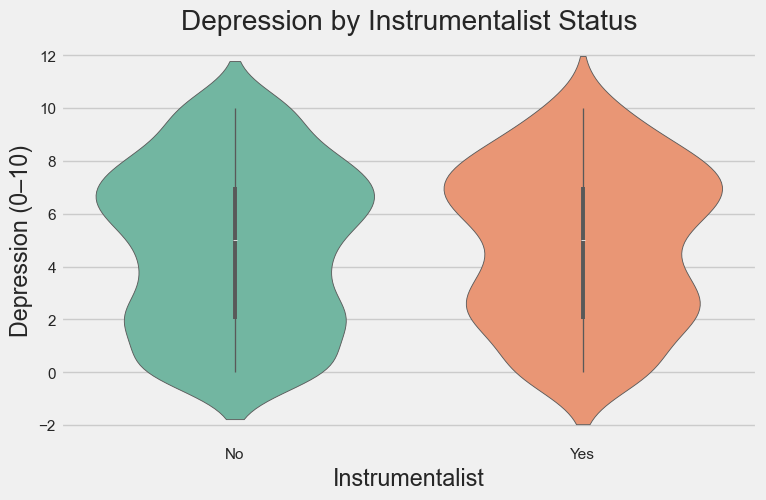

In [33]:
# Comparing depression distribution by instrumentalist status using violin plot
# Shows density, median, and spread per group
# Supports differences aligned with statistical tests
plt.figure(figsize=(8,5))
sns.violinplot(x='Instrumentalist', y='Depression', data=df, palette='Set2')
plt.title('Depression by Instrumentalist Status')
plt.xlabel('Instrumentalist')
plt.ylabel('Depression (0–10)')
plt.show()

Quick Insight: Distributions suggest differences aligned with T-test findings; active engagement may support well-being.

#### Q8: What correlations exist among mental health and habits?

```python
# Correlation heatmap among health metrics and listening habits
# Quantifies linear relationships with annotations
# Useful for identifying comorbidity and drivers
```

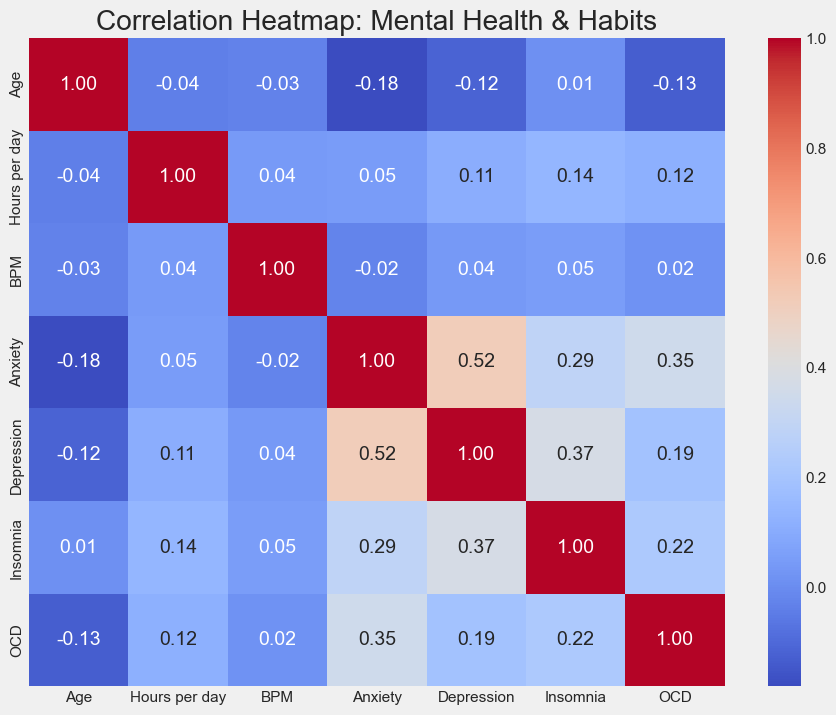

In [34]:
# Correlation heatmap among mental health metrics and habits
# Quantifies linear relationships with annotations
# Useful for identifying comorbidities and drivers
corr_cols = ['Age','Hours per day','BPM','Anxiety','Depression','Insomnia','OCD']
plt.figure(figsize=(10,8))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Mental Health & Habits')
plt.show()

Quick Insight: Anxiety–depression comorbidity appears; habits show modest relationships to mental health scores.

#### Q9: How does listening time vary by streaming service?

```python
# Boxplot of hours per day across streaming platforms
# Summarizes per‑platform usage distributions
# Guides product considerations and session prompts
```

C:\Users\mauli\AppData\Local\Temp\ipykernel_30516\3385852477.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Primary streaming service', y='Hours per day', data=df, palette='magma')


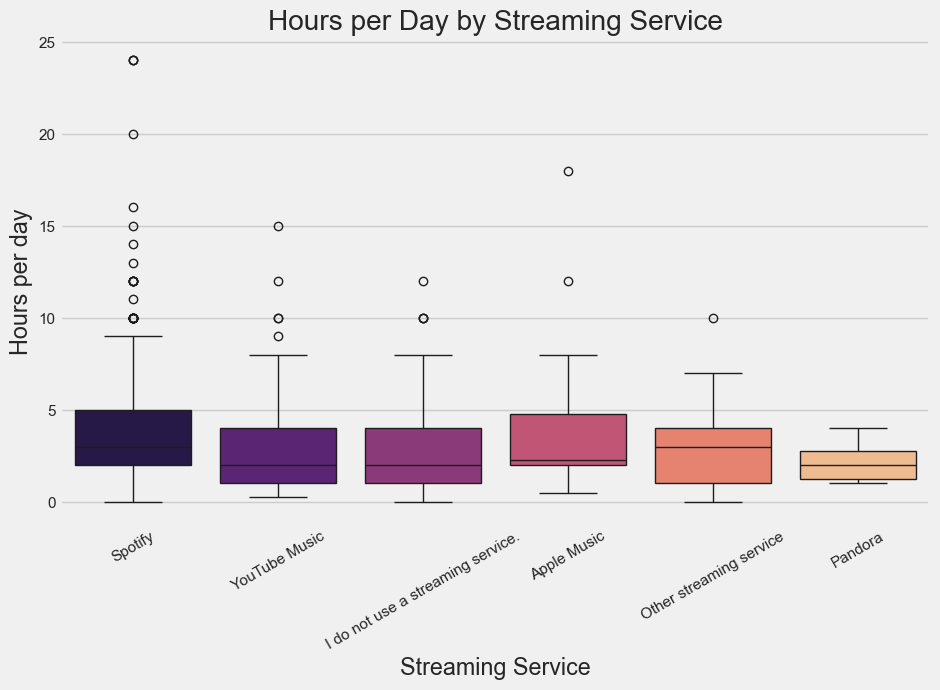

In [35]:
# Comparing listening time by streaming service using boxplot
# Summarizes per-platform usage distributions
# Guides platform-specific product insights
plt.figure(figsize=(10,6))
sns.boxplot(x='Primary streaming service', y='Hours per day', data=df, palette='magma')
plt.xticks(rotation=30)
plt.title('Hours per Day by Streaming Service')
plt.xlabel('Streaming Service')
plt.ylabel('Hours per day')
plt.show()

Quick Insight: Usage intensity differs by platform; product teams can tailor session prompts accordingly.

#### Q10: Do foreign-language listeners report different music effects?

```python
# Countplot comparing music effects by foreign‑language preference
# Shows class distribution by preference group
# Helps understand multilingual content impact
```

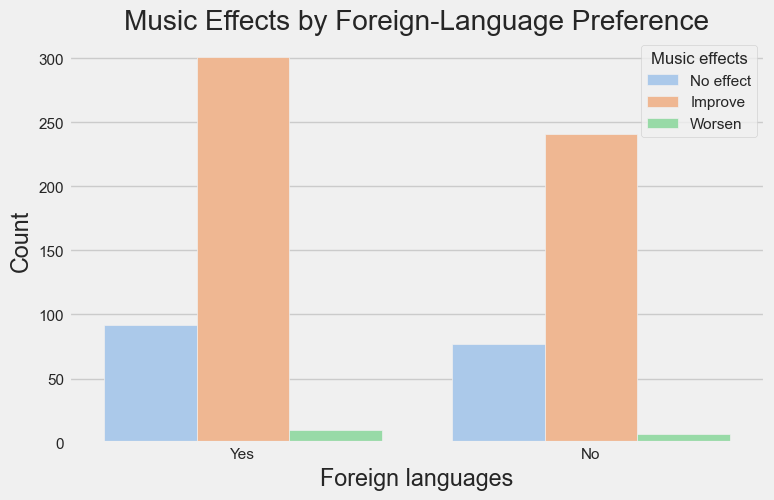

In [36]:
# Comparing music effects across foreign-language preference using countplot
# Shows class distribution by preference group
# Helps understand multilingual content impact
plt.figure(figsize=(8,5))
sns.countplot(x='Foreign languages', hue='Music effects', data=df, palette='pastel', legend=True)
plt.title('Music Effects by Foreign-Language Preference')
plt.xlabel('Foreign languages')
plt.ylabel('Count')
plt.show()

Quick Insight: Preferences correlate with perceived effects; multilingual content may broaden positive experiences.

## Step 8: Conclusion

### Summary of Findings
- Music is largely perceived as beneficial ('Improve'), with minority outcomes varying by genre and engagement.
- Anxiety and depression show moderate correlation; usage patterns differ across platforms and demographics.
- The classifier performs well on the majority class but needs support for minority classes.

### Limitations
- Age skew and self-reported measures; limited context about sessions and lyrics.
- Cross-sectional design; causal inference is out of scope.

### Future Improvements
- Enrich features (NLP on lyrics, mood labels, context), balance classes (SMOTE), and tune models (GridSearchCV with f1_macro).
- Add longitudinal data and calibrated probabilities; compare alternative models.

### Key Takeaways
Music habits, preferences, and engagement styles relate to mental health perceptions. With better features, balanced data, and tuned models, systems can responsibly personalize experiences to support focus and well-being while transparently communicating limitations.

# PROJECT SUMMARY

### Overview
This investigation examines the association between music‑listening practices and self‑reported mental‑health outcomes using a structured survey instrument. We articulate empirical regularities across preference, engagement, and platform usage, and formalize prediction of perceived musical effect (Improve / No effect / Worsen) via supervised learning.

### Objectives
- Institute a reproducible data‑conditioning pipeline (standardization of frequency fields, categorical encoding, treatment of missingness).
- Characterize distributions and dependencies through disciplined EDA.
- Validate putative group differences with inferential statistics (e.g., t‑tests).
- Construct, evaluate, and interpret a Random Forest classifier under class imbalance.

### Methods
- Preprocessing: selective feature inclusion; type coercion; label/one‑hot encoding; stratified train/test partitioning.
- EDA: histograms for age/BPM/usage; box/violin plots for genre and instrumentalist contrasts; correlation heatmaps for mental‑health metrics.
- Inference: hypothesis testing to corroborate observed contrasts.
- Modeling: class‑aware evaluation (classification report with macro metrics); normalized confusion matrices; analysis of feature importance.

### Principal Findings
- The majority of respondents report beneficial effects of music; minority outcomes are comparatively sparse and more difficult to predict.
- Genre context and engagement intensity exhibit systematic associations with anxiety/depression profiles.
- Correlations among mental‑health variables indicate comorbid structure; BPM and usage show modest linear relations.

### Technical Stack
Python (Pandas, NumPy), visualization (Matplotlib, Seaborn), inference (SciPy), learning (scikit‑learn: RandomForest, metrics).

### Implications
Findings support principled, context‑aware content recommendations, emphasizing transparency and sensitivity to diverse experiences.

### Limitations
Cross‑sectional, self‑reported data constrain causal claims; class imbalance and limited contextual signals challenge minority‑class performance.

### Future Work
Richer context (session, mood, lyrical sentiment), class balancing (SMOTE), calibration and hyperparameter tuning, and longitudinal designs to capture dynamics.

### Conclusion
A coherent pipeline—cleaning, EDA, inference, and modeling—yields an academically defensible account of how music engagement aligns with mental‑health perceptions, offering practical and ethical guidance for research and product development.